# Mod 4 Project - Housing Price Forecasting

### Business Case
#### An alternative investment company (e.g YieldStreet) has just launched a new fund looking to invest in residential real estate projects in the Bay Area
- They have a small team dediated to this project / region and want to prioritize 5 zip code sized regions
- Priority timeframe for returns is ~2 years (they want excited early adopters)
- High tolerance for risk

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Data Overview
- Zillow housing research  
    - 1996-2018 timeframe  
    - Split by zipcode
    - Monthly median home sale price across all home types  
    
#### **Note: Data is **already smoothed and seasonally adjusted ** 

## Step 1: Key Data Ingestion Steps:
- Import zillow dataset
- Import Bay Area zipcode list
- Create city / metro region zipcode groupings

    

In [168]:
df_zillow_national = pd.read_csv("zillow_data.csv")
df_bayarea_zips = pd.read_csv("bayarea_zipcodes.csv")

df_bayarea = df_zillow_national[df_zillow_national['RegionName'].isin(df_bayarea_zips['ZIP'])]
df_bayarea = df_bayarea.drop(['RegionID'],axis=1)
#display(df_bayarea)
metro_zip = {}
city_zip = {}

cols_to_drop = list(df_bayarea.columns)
save = ['RegionName', 'City', 'Metro']
for item in save:
    cols_to_drop.remove(item)
df_bayarea_ccz = df_bayarea.drop(cols_to_drop, axis = 1)
#display(df_bayarea_ccz) 

for metro in df_bayarea_ccz['Metro'].unique():
    metro_zip[metro] = list(df_bayarea_ccz.loc[df_bayarea_ccz['Metro']==metro, 'RegionName'])

for city in df_bayarea_ccz['City'].unique():
    city_zip[city] = list(df_bayarea_ccz.loc[df_bayarea_ccz['City']==city, 'RegionName'])

all_zips = list(df_bayarea_ccz['RegionName'].unique())
#print(all_zips)

### 1: Key Data Ingestion Steps:
- Melt data from wide to long format
- Create grouped version of long data format to call specific zipcodes

#### Note: since we don't know the relative volumes of sales across zip codes we can't aggregate data beyond a single zip code

In [103]:
# Partitioning ID Variables
id_vars_list = ['RegionName', 'City', 'State', 'Metro', 'CountyName','SizeRank']
value_vars_list = df_bayarea.columns.drop(id_vars_list)

df_bayarea_melted = pd.melt(df_bayarea, id_vars = ['RegionName'], value_vars = value_vars_list, var_name = 'time' )
df_bayarea_melted['time'] = pd.to_datetime(df_bayarea_melted['time'])

df_zips = df_bayarea_melted
df_zips['value'].fillna(method = 'bfill', inplace = True)

df_zips.rename(columns = {'RegionName':'zipcode'}, inplace = True)

df_zips_gb = df_zips.groupby(by = 'zipcode')

# Step 2: EDA and Visualization
- Created two functions for viewing single zipcodes or multiple zip code price data over time (e.g. all San Francisco zips)
- Saved overview charts of each major metro area's housing price change over time by zip code

In [6]:
def zipconcat (row):
    """ Reformats zipcode integer value to string alphanumeric to solve an seaborn plotting bug"""
    return 'zip'+str(row)

def multi_lineplot (grouped_data, list_of_zips, title):
    """ Creates and saves a multi-line plot of housing price over time by zipcode for a region

    Arguments:
    grouped_data -- group object of long-format housing price values with date and zipcode
    list_of_zips -- list of integer zipcodes to plot
    title -- string that becomes the filename of saved image
    """
    df = grouped_data.get_group(list_of_zips[0])
    if len(list_of_zips) > 1:
        for item in list_of_zips[1:]:
            df = df.append(grouped_data.get_group(item))
    df['zipcode'] = df['zipcode'].apply(zipconcat)
    sns.set(rc={'figure.figsize':(15,6)})
    sns.lineplot(x = 'time', y = 'value', hue = 'zipcode', data = df, legend='brief').set_title(title)
    plt.savefig(f'{title}.png')
    plt.clf()

def lineplot (df, x, y, title):
    """ Creates and saves a single-line plot of housing price over time for a zipcode

    Arguments:
    df -- long-format housing price values with date
    x -- string column name
    y -- string column name
    title -- string that becomes the filename of saved image
    """
    sns.set(rc={'figure.figsize':(15,6)})
    sns.lineplot(x = x, y = y, data = df, legend='brief').set_title(title)
    plt.savefig(f'{title}.png')
    plt.clf()   

# Create a lineplot of housing prices for each metro region
for metro_region in metro_zip.keys():
    multi_lineplot(df_zips_gb, metro_zip[metro_region], 'Metro-Region_'+metro_region+'_Price-($)')


NameError: name 'San' is not defined

### 2. Initial price line chart review: See San Jose "Metro Reg. Zips - San Francisco - Price ($).png"

<img src="Metro-Region_San Jose_Price-($).png">

- High recent growth in housing prices
- Distinct downswing or flattening between 2007 and 2010
- Heterogeneity in both 1996-2008 growth and in 2008-2018 growth rates across zip codes


## Step 3: ARIMA Forecasting
- **Note:** the zillow dataset we are using has already been smoothed for seasonality
- We will use an integrated ARIMA model (the primary difference beteen SARIMA and ARIMA is seasonality)
- **Journal of Real Estate Economics** https://onlinelibrary.wiley.com/doi/abs/10.1111/1540-6229.00064
    - "While price changes on any particular home are difficult to predict, aggregate home price changes are forecastable. In this context, this paper compares the forecasting performance of three types of univariate time series models: ARIMA, GARCH and regime‐switching. The underlying intuition behind regime‐switching models is that the series of interest behaves differently depending on the realization of an unobservable regime variable. Regime‐switching models are a compelling choice for real estate markets that have historically displayed boom and bust cycles. However, we find that, while regime‐switching models can perform better in‐sample, simple ARIMA models generally perform better in out‐of‐sample forecasting."

### Reviewing PACF and ACF Correlograms
- Making sure autocorrelation drops off within a few lags
- Ensuring our range of values we will test for pqr inputs is complete

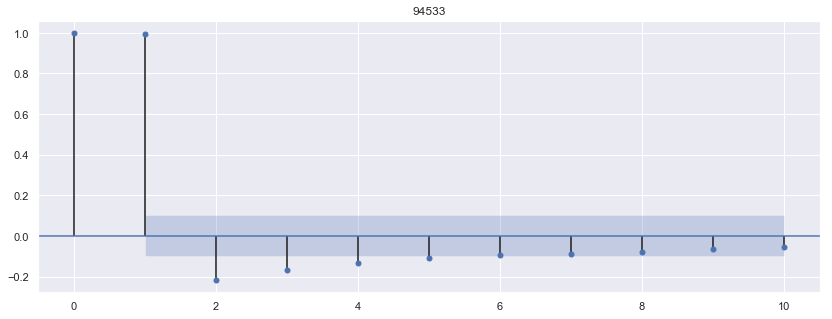

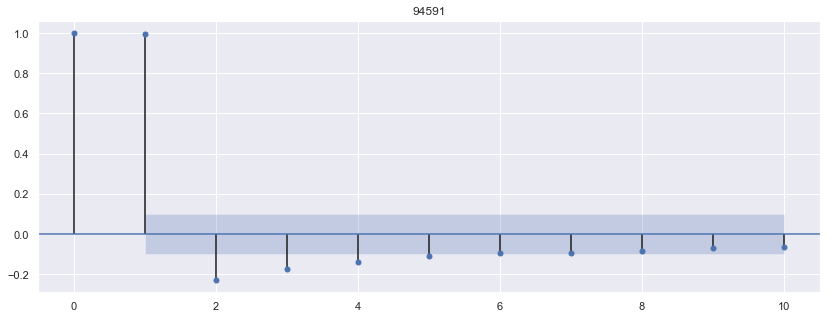

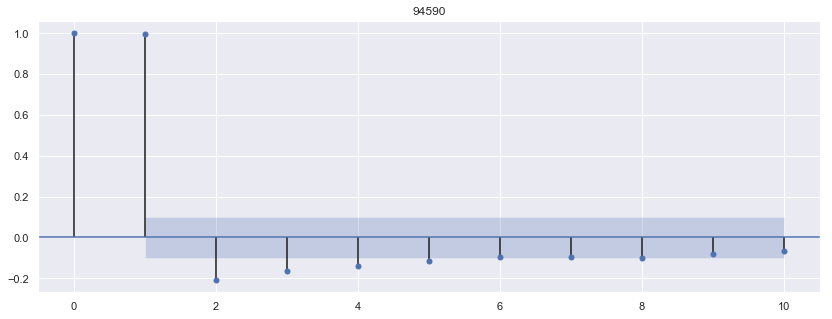

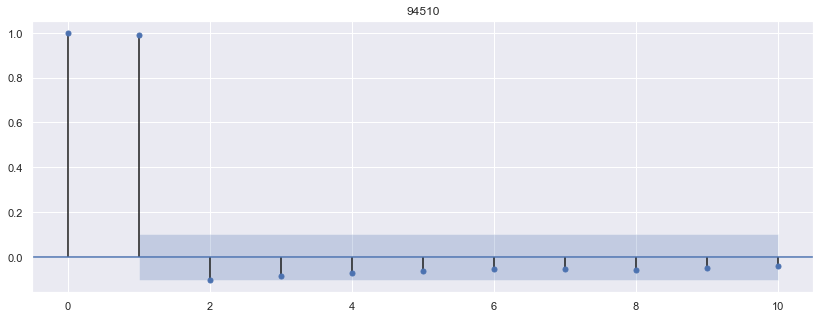

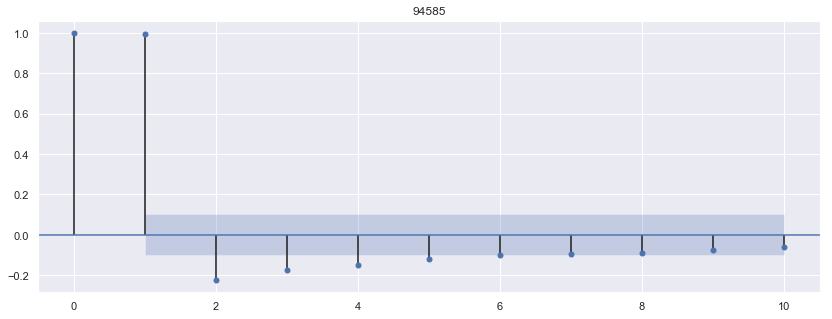

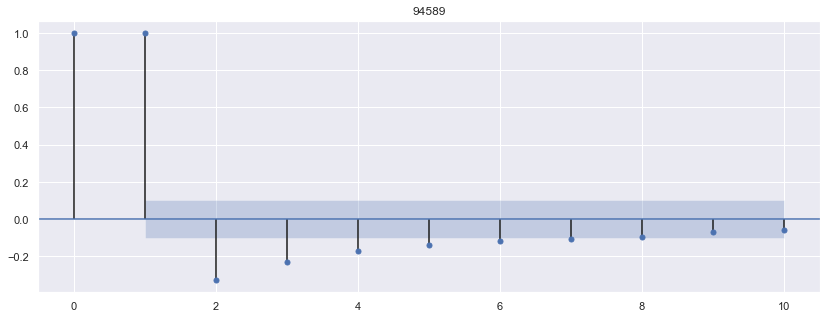

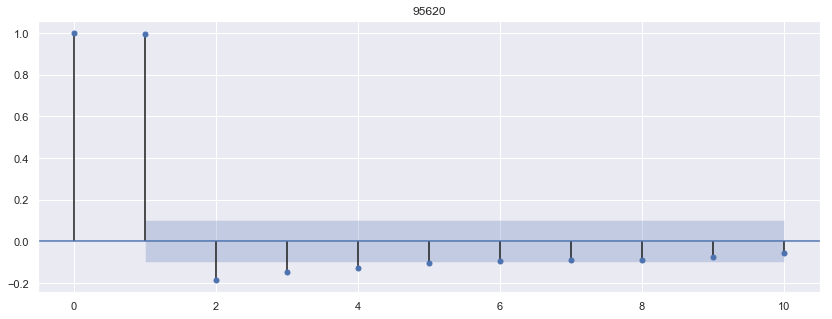

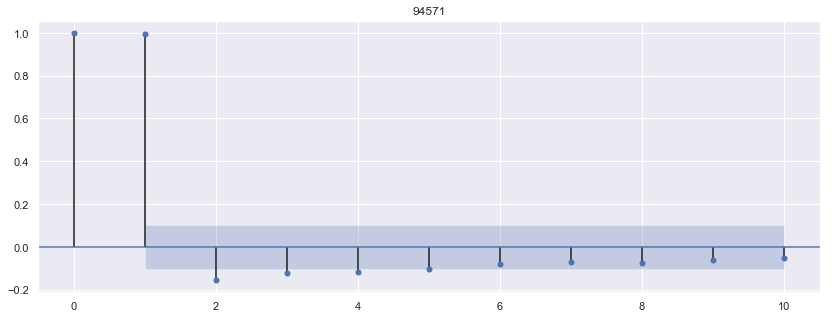

In [174]:
# PACF and ACF Correlograms
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

from matplotlib.pylab import rcParams

rcParams['figure.figsize'] = 14, 5

def create_pacf_df(zipcode):
    """ Returns a dataframe with a datetime index, time column, and housing index value column

    Arguments:
    zipcode -- integer zipcode value
    """
    pacf_df = df_zips_gb.get_group(zipcode)
    pacf_df = pacf_df.loc[:, ['time', 'value']] 
    pacf_df.set_index('time', inplace=True)
    return pacf_df

# Create list of PACF graphs for a region
pacf_list = []
region = 'Vallejo'
for zippy in metro_zip[region]:
    graph = plot_pacf(create_pacf_df(zippy), title = str(zippy), alpha = .1, lags = 10)
    pacf_list.append(graph)

#display(pacf_list[0])

### 3. ARIMA Modeling
- Compare pdq values and choose based on AIC score

In [88]:
import itertools
import statsmodels.api as sm
from statsmodels.tsa.arima_model import ARIMA
import matplotlib.pyplot as plt

def create_ts(zipcode):
    """Returns dataframe with single column of housing price and has datetime index, takes single integer zipcode"""
    df_temp = df_zips_gb.get_group(zipcode)
    df_temp.set_index(df_temp['time'], inplace=True)
    df_temp.drop(labels = ['time', 'zipcode'], axis = 1, inplace = True)
    return df_temp   

test_zip = 94533
def arima_pdq_comparison(zipcode):
    """Returns list of two-item lists with a pdq combination and the AIC output value, takes integer zipcode value"""
    df_test = create_ts(zipcode)
    p = range(0,4)
    d = range(0,4)
    q = range(0,4)
    pdq = list(itertools.product(p, d, q))
    
    aic = []
    for combo in pdq:
        try:
            model = ARIMA(df_test, order = combo)
            output = model.fit()
            aic.append([combo, output.aic])
        except:
            continue
    return aic

test_results = arima_pdq_comparison(test_zip)

for item in test_results:
    print(item[0],' - AIC Value = ', item[1])    

C:\Users\John Kline\.conda\envs\learn-env\lib\site-packages\statsmodels\base\model.py:508: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)
C:\Users\John Kline\.conda\envs\learn-env\lib\site-packages\statsmodels\base\model.py:508: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)
C:\Users\John Kline\.conda\envs\learn-env\lib\site-packages\statsmodels\base\model.py:508: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)
C:\Users\John Kline\.conda\envs\learn-env\lib\site-packages\statsmodels\base\model.py:508: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)
C:\Users\John Kline\.conda\envs\learn-env\lib\site-packages\statsmodels\base\model.py:508: ConvergenceWa

## AIC Value Selection
- Lowest AIC value comes at (3, 2, 3) with AIC = 5124.2
- Limited difference in AIC values across combinations - typically range from 5,125 to 5,300

### 3. Graphing ARIMA forecasts

<Figure size 1008x360 with 0 Axes>

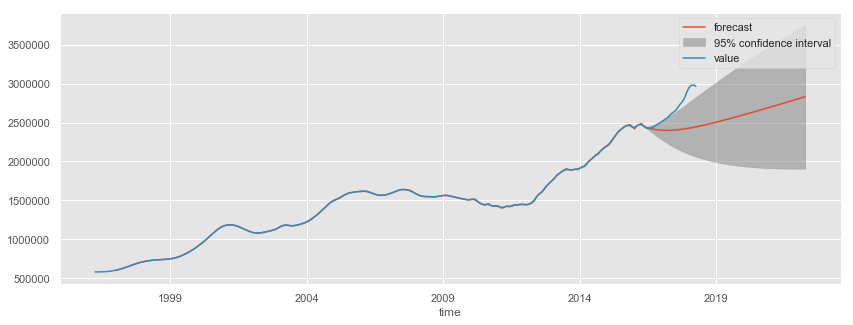

<Figure size 1008x360 with 0 Axes>

<Figure size 1008x360 with 0 Axes>

In [199]:
plt.style.use('ggplot')

zipcode_test = 94010
pdq_combo_test = (3, 2, 3)

def arima_results(zipcode, pdq_combo):
    """ Returns ARIMAResults class object for given zipcode and pdq combination

    Arguments:
    zipcode -- integer zipcode value
    pdq_combo -- three-element tuple of pdq inputs
    """
    model = ARIMA(create_ts(zipcode), order = pdq_combo)
    output = model.fit()
    return output

def arima_forecast(zipc, pdq_combo, break_date, term_date):
    """ Plots forecast graph based on a split / test date and forecast end date

    Arguments:
    zipc -- integer zipcode value
    pdq_combo -- three-element tuple of pdq inputs
    break_date -- end of test data / start of forecast
    term_date -- end of forecast period
    """    
    df_orig = create_ts(zipc)
    df_trial = df_orig[:break_date]
    model = ARIMA(df_trial, order = pdq_combo)
    out = model.fit()
    plt.clf()
    fig, ax = plt.subplots()
    fig = out.plot_predict(start_date, term_date, plot_insample = False, ax = ax)
    ax = df_orig.plot(ax=ax)
    plt.show()

start_date = '1997-01-01'
break_date = '2016-05-01'
end_date = '2022-04-01'
arima_forecast(zipcode_test, pdq_combo_test, break_date, end_date)
arima_forecast_save(zipcode_test, pdq_combo_test, break_date, end_date, '94010 Forecast Test - 1')

zipcode_test = 94121
pdq_combo_test = (3, 2, 3)
start_date = '1997-01-01'
break_date = '2016-05-01'
end_date = '2022-04-01'

<Figure size 936x432 with 0 Axes>

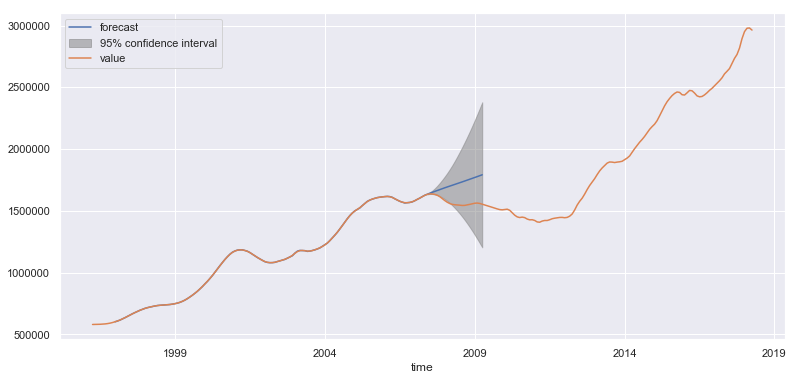

<Figure size 936x432 with 0 Axes>

<Figure size 936x432 with 0 Axes>

In [200]:
zipcode_test = 94010
start_date = '1997-01-01'
break_date = '2007-05-01'
end_date = '2009-04-01'
arima_forecast(zipcode_test, pdq_combo_test, break_date, end_date)
arima_forecast_save(zipcode_test, pdq_combo_test, break_date, end_date, '94010 Forecast Test - 2')

<Figure size 936x432 with 0 Axes>

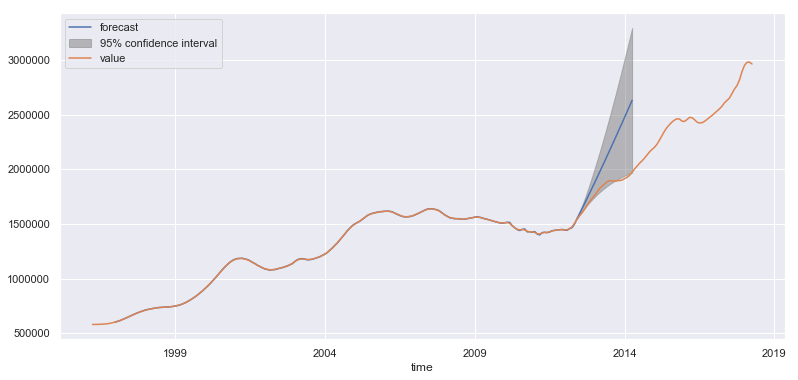

<Figure size 936x432 with 0 Axes>

<Figure size 936x432 with 0 Axes>

In [201]:
zipcode_test = 94010
start_date = '1997-01-01'
break_date = '2012-05-01'
end_date = '2014-04-01'
arima_forecast(zipcode_test, pdq_combo_test, break_date, end_date)
arima_forecast_save(zipcode_test, pdq_combo_test, break_date, end_date, '94010 Forecast Test - 3')

<Figure size 936x432 with 0 Axes>

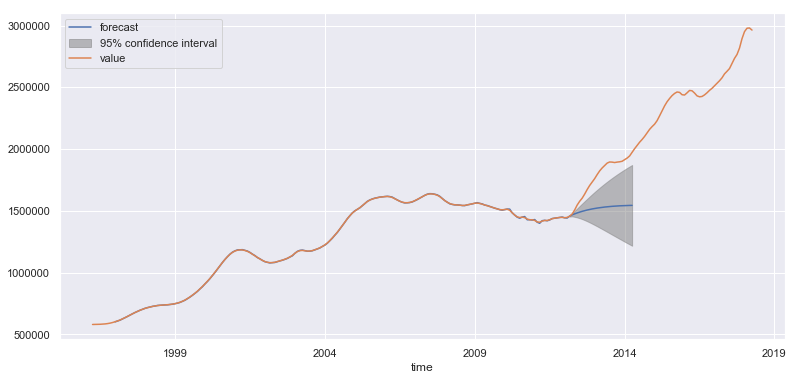

<Figure size 936x432 with 0 Axes>

<Figure size 936x432 with 0 Axes>

In [202]:
zipcode_test = 94010
start_date = '1997-01-01'
break_date = '2012-02-01'
end_date = '2014-04-01'
arima_forecast(zipcode_test, pdq_combo_test, break_date, end_date)
arima_forecast_save(zipcode_test, pdq_combo_test, break_date, end_date, '94010 Forecast Test - 4')

<Figure size 936x432 with 0 Axes>

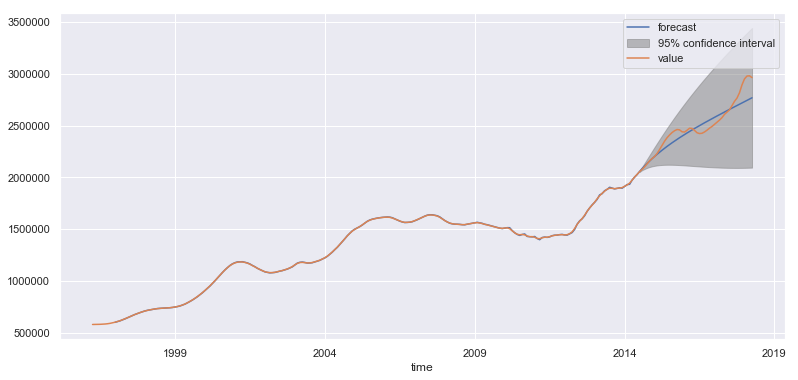

<Figure size 936x432 with 0 Axes>

<Figure size 936x432 with 0 Axes>

In [203]:
zipcode_test = 94010
start_date = '1997-01-01'
break_date = '2014-06-01'
end_date = '2018-04-01'
arima_forecast(zipcode_test, pdq_combo_test, break_date, end_date)
arima_forecast_save(zipcode_test, pdq_combo_test, break_date, end_date, '94010 Forecast Test - 5')

### 3. Generating 2-Year Forecasts Using ARIMA Model Outputs
- Generate forecasted 2-year housing price index growth for each zip code
- Generate forecasted 2-year housing price index 95% lower-bound for each zip code

In [155]:
ziplist = [94121, 94010]
ev_dict = {}
ub_dict = {}
lb_dict = {}

pdq_combo = (3, 2, 2)

test_zip = 94010

for zipc in all_zips:
    try:
        out = arima_results(zipc, pdq_combo)
    except:
        try: 
            out = arima_results(zipc, (pdq_combo[0], pdq_combo[1], pdq_combo[0] + 1))
        except:
            try:
                out = arima_results(zipc, (pdq_combo[0], pdq_combo[1], pdq_combo[0] - 1))
            except:
                out = arima_results(zipc, (2, 2, 1))
               
    forecast = out.forecast(steps = 24, alpha = .05)

    # expected value
    predicted = forecast[0][-1]
    today = forecast[0][0]
    increase = (predicted-today)/today
    ev_dict[zipc] = increase

    # upper bound
    ub_dict[zipc] = (forecast[2][-1][1]-today)/today

    # lower bound
    lb_dict[zipc] = (forecast[2][-1][0]-today)/today
    

#print(ev_dict)


C:\Users\John Kline\.conda\envs\learn-env\lib\site-packages\statsmodels\base\model.py:508: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)
{94109: 0.07697182948314071, 94565: 0.19015895944770797, 94501: 0.05344470825409606, 94110: 0.17274842175228178, 94558: 0.1369539828257759, 94533: 0.13189284327725964, 94536: 0.1450674813153233, 94544: 0.06227512587062877, 94509: 0.1777500345794956, 94122: 0.11191442868125995, 95035: 0.37617556634594784, 94538: 0.11485525301776583, 94541: -0.002678738261972289, 94513: 0.11492747750379666, 94587: 0.07892241823770997, 94568: 0.038972402234848165, 94080: 0.017852393444788544, 94112: 0.15961286277380976, 94087: 0.27796848543323827, 94591: 0.027812615433104034, 94086: 0.2521769646573952, 94553: 0.0693519153408232, 94015: -0.06284752938691601, 94115: 0.06341124679388117, 94117: 0.12721926250209237, 94121: 0.17742425368484904, 94611: -0.08508809400282068, 94550: 0.09756383

### 3. Forecast Outputs
- Expected Value (EV): percentage difference between current housing index price and forecasted housing index in 2 years given ARIMA model for that zip code
- Lower Bound (LB): percentage difference between current housing index price and lower-bound forecasted index in 2 years given ARIMA model for that zip code
- List of all zipcodes sorted by descending EV forecast

In [165]:
for key, value in sorted(ev_dict.items(), key = lambda x:x[1], reverse = True):
    print(key, "- EV:", round(value, 2), ', LB', round(lb_dict[key],2))

94572 - EV: 0.47 , LB -0.04
94043 - EV: 0.39 , LB 0.17
95035 - EV: 0.38 , LB 0.08
94089 - EV: 0.31 , LB 0.05
94063 - EV: 0.3 , LB 0.01
94087 - EV: 0.28 , LB 0.06
94038 - EV: 0.27 , LB 0.08
94805 - EV: 0.27 , LB -0.21
94086 - EV: 0.25 , LB 0.03
94571 - EV: 0.25 , LB -0.14
94590 - EV: 0.24 , LB -0.13
94560 - EV: 0.24 , LB 0.0
94066 - EV: 0.23 , LB -0.0
94564 - EV: 0.2 , LB -0.06
94565 - EV: 0.19 , LB -0.23
94019 - EV: 0.19 , LB 0.02
94566 - EV: 0.18 , LB -0.07
94804 - EV: 0.18 , LB -0.46
94509 - EV: 0.18 , LB -0.3
94121 - EV: 0.18 , LB 0.04
94601 - EV: 0.17 , LB -0.11
94965 - EV: 0.17 , LB -0.21
94110 - EV: 0.17 , LB -0.07
94107 - EV: 0.17 , LB -0.2
94563 - EV: 0.17 , LB -0.04
94704 - EV: 0.16 , LB 0.02
94112 - EV: 0.16 , LB -0.14
94024 - EV: 0.16 , LB -0.08
94555 - EV: 0.16 , LB -0.12
94518 - EV: 0.16 , LB -0.21
94545 - EV: 0.16 , LB -0.14
94116 - EV: 0.15 , LB -0.08
94549 - EV: 0.15 , LB -0.31
94559 - EV: 0.15 , LB -0.08
94595 - EV: 0.15 , LB -0.28
94301 - EV: 0.15 , LB -0.09
94598 - E

### 3. Top Zipcode Forecast Graphs
- Saving top growth zipcode forecast graphs for use in presentations

<Figure size 1008x360 with 0 Axes>

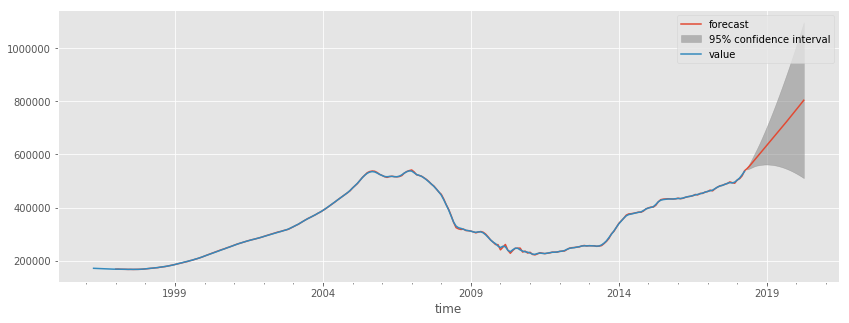

<Figure size 1008x360 with 0 Axes>

<Figure size 1008x360 with 0 Axes>

<Figure size 936x432 with 0 Axes>

<Figure size 936x432 with 0 Axes>

<Figure size 936x432 with 0 Axes>

<Figure size 936x432 with 0 Axes>

In [167]:
zipcode_test = 94572
start_date = '1997-01-01'
break_date = '2018-04-01'
end_date = '2020-04-01'
arima_forecast(zipcode_test,(3,2,1), break_date, end_date,)

pdq_combo = (3,2,1)

def arima_forecast_save(zipc, pdq_combo, break_date, term_date, title):
    """ Saves forecast graph based on a split / test date and forecast end date

    Arguments:
    zipc -- integer zipcode value
    pdq_combo -- three-element tuple of pdq inputs
    break_date -- end of test data / start of forecast
    term_date -- end of forecast period
    title -- title of graph and filename of saved image
    """    
    df_orig = create_ts(zipc)
    df_trial = df_orig[:break_date]
    model = ARIMA(df_trial, order = pdq_combo)
    out = model.fit()
    plt.clf()
    fig, ax = plt.subplots()
    fig = out.plot_predict(start_date, term_date, plot_insample = False, ax = ax)
    ax = df_orig.plot(ax=ax)
    sns.set(rc={'figure.figsize':(13,6)})
    plt.savefig(f'{title}.png')
    plt.clf()   

graph_list = [94572, 94043, 95035, 94089, 94063]

for zipc in graph_list:
    title = str(zipc)+' - 2-Yr Forecast'
    arima_forecast_save(zipc, pdq_combo, break_date, end_date, title)




### 4. Additional Analysis
- Downloaded additional housing data inputs from Zillow research page
    - Unfortunately most housing data inputs don't start until 2008 or later
    - Many data sources are not available monthly or at the zip code level
- Imported BSI (Buyer-Seller Index), a measure of the ratio of buyers and sellers in a market at a given time to test it as an additional predictive value, or leading indicator of price performance
    - Melted into long format
    - Wrote a function for joining a zipcode list and the BSI data for that zip code
    - Unfortunately BSI data is only available for a subset of the larger zip codes

In [179]:
df_bsi_raw = pd.read_csv("BuyerSellerIndexCrossTime_Zip.csv")
df_bsi_wide = df_bsi_raw[df_bsi_raw['RegionName'].isin(df_bayarea_zips['ZIP'])]
df_bsi_wide = df_bsi_wide.drop(['RegionID', 'RegionType', 'StateName', 'SizeRank', 'MSA', 'MSARegionID'], axis = 1)

id_vars_bsi = ['RegionName']
value_vars_bsi = df_bsi_wide.columns.drop(id_vars_bsi)

df_bsi = pd.melt(df_bsi_wide, id_vars = ['RegionName'], value_vars = value_vars_bsi, var_name = 'time' )
df_bsi['time'] = pd.to_datetime(df_bsi['time'])
df_bsi.rename(columns = {'RegionName':'zipcode'}, inplace = True)
df_bsi_gb = df_bsi.groupby(by = 'zipcode')

def join_bsi(zipcode, df1, df2):
    """ Joins zipcode dataframe and BSI dataframe using grouped long format dataframes

    Arguments:
    zipcode -- integer zipcode value
    df1 -- price group data object of long-format dataframe, grouped on zipcode
    df2 -- BSI group data object of long-format dataframe, grouped on zipcode
    """    
    base = df1.get_group(zipcode)
    add = df2.get_group(zipcode)
    add = add.drop(['zipcode'], axis = 1)
    joined = base.set_index('time').join(add.set_index('time'), how = 'left', lsuffix = '_price', rsuffix = '_bsi')
    return joined.dropna()


#print(df_bsi_gb.get_group(94010))
#print(df_zips_gb.get_group(94010))
test_bsi = join_me_daddy(94010, df_zips_gb, df_bsi_gb)
test_bsi['value_price'] = test_bsi['value_price'].diff(periods = 1)
#display(test_bsi)

#sns.regplot(x=test_bsi['value_bsi'], y=test_bsi['value_price'])

In [51]:
test_bsi.head()

,zipcode,value_price,value_bsi
time,,,
2010-11-01,94010,NaN,0.64
2010-12-01,94010,900.0,0.45
2011-01-01,94010,-5900.0,0.36
2011-02-01,94010,-12000.0,0.27
2011-03-01,94010,-2400.0,0.18


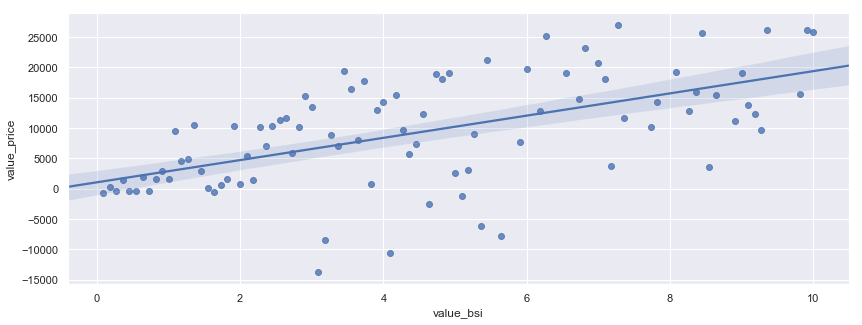

In [196]:
def bsi_zipcode_plot(zipcode, df_bsi):
    """ Plots BSI vs. housing price data for a given zipcode

    Arguments:
    zipcode -- integer zipcode value
    df_bsi -- joined, ungrouped dataframe in long format with housing price and BSI data
    """    
    fig, ax1 = plt.subplots(figsize=(10,6))
    color = 'tab:green'
    ax1.set_title(str(zipcode)+' - House Price vs BSI', fontsize=16)
    ax1.set_xlabel('Month', fontsize=16)
    ax1.set_ylabel('BSI', fontsize=16, color='blue')
    ax2 = sns.lineplot(x=test_bsi.index, y='value_bsi', data = df_bsi, color='blue')
    ax1.tick_params(axis='y')
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Price', fontsize=16, color='red')
    ax2 = sns.lineplot(x=test_bsi.index, y='value_price', data = df_bsi, sort=False, color='red')
    ax2.tick_params(axis='y', color=color)
    plt.show()

test_zipcode = 94110
def differenced_bsi_regplot(zipcode):
    """ Plots BSI vs. one-period differenced housing price data for a given zipcode

    Arguments:
    zipcode -- integer zipcode value
    """    
    df_test_bsi = None
    df_test_bsi = join_bsi(zipcode, df_zips_gb, df_bsi_gb)
    df_test_bsi['value_price'] = df_test_bsi['value_price'].diff(periods = 1)
    df_test_bsi['value_price'] = df_test_bsi.iloc[:,1:2].rolling(window=3).mean()
    df_test_bsi= df_test_bsi.fillna(method = 'bfill')
    sns.regplot(x = df_test_bsi['value_bsi'], y = df_test_bsi['value_price'])

#bsi_zipcode_plot(zipcode, df_test_bsi)

def differenced_bsi_lineplot(zipcode):
    """ Plots BSI vs. one-period differenced housing price data for a given zipcode

    Arguments:
    zipcode -- integer zipcode value
    """    
    df_test_bsi = None
    df_test_bsi = join_bsi(zipcode, df_zips_gb, df_bsi_gb)
    df_test_bsi['value_price'] = df_test_bsi['value_price'].diff(periods = 1)
    df_test_bsi['value_price'] = df_test_bsi.iloc[:,1:2].rolling(window=3).mean()
    df_test_bsi= df_test_bsi.fillna(method = 'bfill')
    bsi_zipcode_plot(zipcode, df_test_bsi)

differenced_bsi_regplot(94110)

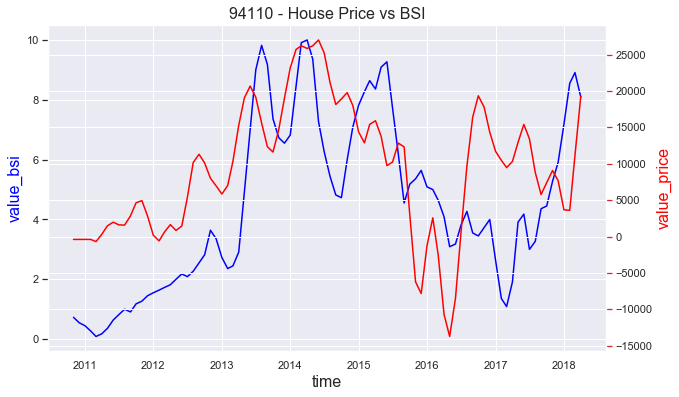

In [197]:
differenced_bsi_lineplot(94110)

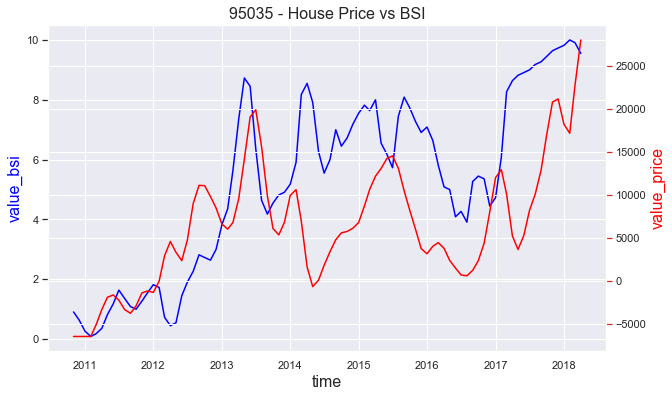

In [198]:
differenced_bsi_lineplot(95035)

 Step 5: Interpreting Results

We have identified 5-6 zip codes in the San Francisco Bay Area that have the highest chance predicted percentage housing price growth over the nest two years.  The analysis is based on more than 20 years of housing price index data from Zillow's research team, and relies on an ARIMA regression to forecast housing prices into future months.  A summary of the selected zip codes is below:  
  
| **Zipcode** | Forecast 2-Yr Growth | 97.5% Lower-Bound 2-Yr Forecast | 
| ---- | ---- | ---- |  
| 94572 | 47 % | -4 % |  
| 94043 | 39 % | 17 % |  
| 95035 | 38 % | 8 % |  
| 94089 | 31 % | 5 % |  
| 94063 | 30 % | 1 % |  
| 94087 | 28 % | 6 % |  

Furthermore, we have reviewed a key indicator of buyer/supplier demand ratios using another Zillow-produced metric, the Buyer-Seller Index (BSI), for the two zipcodes within our top 10 highest-growth forecast list.  For both of these, the BSI has approximately tracked housing price growth rates over the last 8 years, and for both, the BSI value is at a historical high point currently (8-10 on a scale of 0 to 10).  This point supports our analysis based solely on historical price patterns.

We also want to be sensitive to potential downside risk - and as such have included a metric on the lower-bound of the projected housing price growth based on our ARIMA forecast model.  For all except the top-growth zipcode, the lower-bound price growth is still positive, and as much as 40% of the expected value growth rate.  However, our top-forecast growth zipcode has a slightly negative lower-bound rate, representing more than a 50% swing in housing price.  This appears to be a high-variance housing price region, and the client may want to deprioritze this region in favor of lower-variance, also high-growth forecast regions.

One of the primary reasons growth rates are so high for these zipcodes is that the starting average home price value in these zipcodes is low to begin with.  Therefore, relatively smaller price increases compared to other zipcodes are resulting in higher percentage growth.  This is fine, as our client is looking to maximize growth on a per-dollar basis, rather than a per-unit basis. Based on a survey of the zipcodes, these are smaller, more coastal, non-central areas near either Palo Alto, Berkeley, or other major metro centers that may be finally being more fully penetrated by high-income residents.  It may be worth looking into whether there are any idiosyncratic charactaristics of these areas that might imply a price ceiling (e.g waste treatment plants, street accessibility issues, etc. 

A limitation of the identified zipcodes is that these are smaller regions, often less than half the size or even a fifth the size of the median zipcode in the region.  Therefore, the investment team may need to move further down the list of prioritized regions to find enough potential acquisition targets.

Finally - an important caveat is that our ARIMA model forecasting is highly sensitive to relatively recent upturns or downturns within the last few months of data.  We have trained the model on 20+ years of data, which for many zip codes includes several moderate drops or spikes in housing prices (especially circa 2006-2010).  A second caveat is that housing prices were very sensitive to a market-wide housing price bubble deflation in the late 00's, and any investor shoudl be concerned about the possibility of a price deflation event that is not predictable from the existing data.  However, future work should include pressure-testing each 2-year prediction on data that ends 2-10 months prior to the actual end of data to test for sensitivity to end-of-period trends.  

